In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/Base.csv")

df.head()

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,...,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,...,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,...,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,AB,3483,...,0,200.0,0,INTERNET,15.215816,linux,1,1,0,0
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,AA,2339,...,0,200.0,0,INTERNET,3.743048,other,0,1,0,0


In [ ]:
# EDA theo tuổi
age_fraud = (
    df.groupby("customer_age")["fraud_bool"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

age_fraud["fraud_rate"] = age_fraud["mean"] * 100

age_fraud



,customer_age,count,sum,mean,fraud_rate
0,10,20987,74,0.003526,0.352599
1,20,245855,1205,0.004901,0.490126
2,30,311433,2589,0.008313,0.831318
3,40,238712,2876,0.012048,1.204799
4,50,140353,2805,0.019985,1.998532
5,60,34770,1149,0.033046,3.304573
6,70,6517,263,0.040356,4.035599
7,80,1297,64,0.049345,4.934464
8,90,76,4,0.052632,5.263158


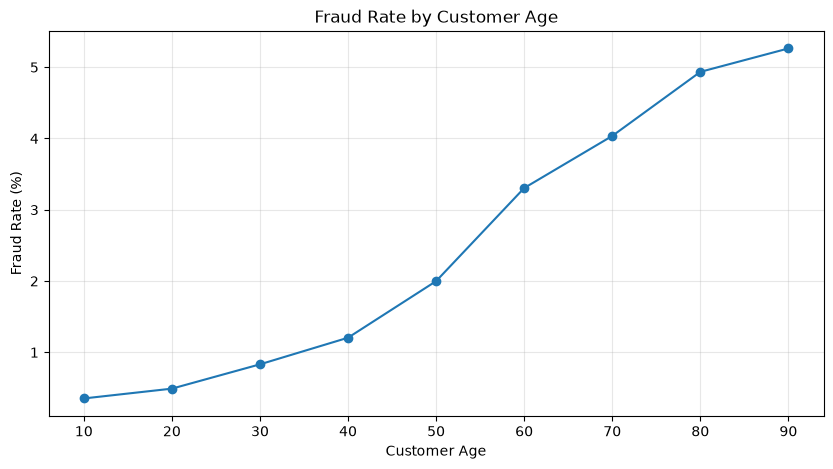

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    age_fraud["customer_age"],
    age_fraud["fraud_rate"],
    marker="o"
)

plt.xlabel("Customer Age")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Customer Age")
plt.grid(alpha=0.3)

plt.show()

In [5]:
# EDA theo income
df["income"].value_counts().sort_index()

income
0.1    157449
0.2     69345
0.3     50833
0.4     81364
0.5     55858
0.6    111973
0.7    105109
0.8    146650
0.9    221419
Name: count, dtype: int64

In [6]:
df["income"].describe()

count    1000000.000000
mean           0.562696
std            0.290343
min            0.100000
25%            0.300000
50%            0.600000
75%            0.800000
max            0.900000
Name: income, dtype: float64

In [7]:
income_fraud = (
    df.groupby("income")["fraud_bool"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

income_fraud["fraud_rate"] = income_fraud["mean"] * 100

income_fraud

,income,count,sum,mean,fraud_rate
0,0.1,157449,909,0.005773,0.577330
1,0.2,69345,438,0.006316,0.631624
2,0.3,50833,338,0.006649,0.664922
3,0.4,81364,597,0.007337,0.733740
4,0.5,55858,444,0.007949,0.794873
5,0.6,111973,983,0.008779,0.877890
6,0.7,105109,927,0.008819,0.881942
7,0.8,146650,1602,0.010924,1.092397
8,0.9,221419,4791,0.021638,2.163771


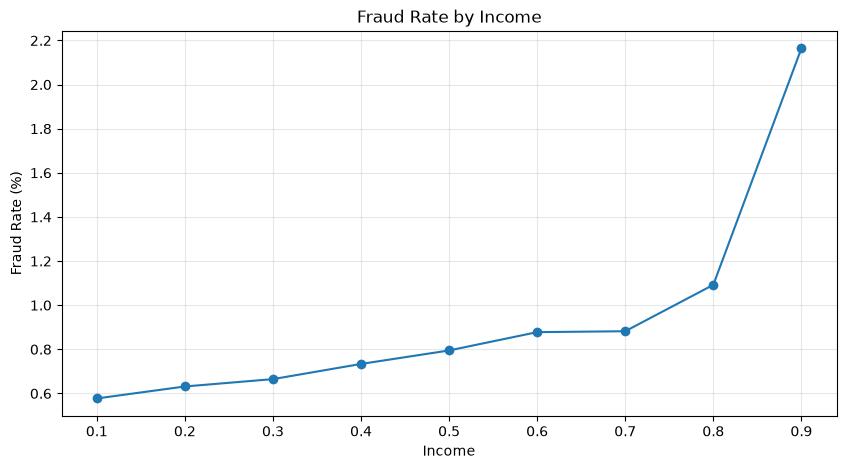

In [8]:
plt.figure(figsize=(10, 5))

plt.plot(
    income_fraud["income"],
    income_fraud["fraud_rate"],
    marker="o"
)

plt.xlabel("Income")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Income")
plt.grid(alpha=0.3)

plt.show()

In [9]:
# EDA theo Credit_risk_score
df["credit_risk_score"].describe()

count    1000000.000000
mean         130.989595
std           69.681812
min         -170.000000
25%           83.000000
50%          122.000000
75%          178.000000
max          389.000000
Name: credit_risk_score, dtype: float64

In [10]:
df["credit_risk_group"] = pd.qcut(
    df["credit_risk_score"],
    q=10,
    duplicates="drop"
)

credit_fraud = (
    df.groupby("credit_risk_group", observed=True)["fraud_bool"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

credit_fraud["fraud_rate"] = credit_fraud["mean"] * 100

credit_fraud

,credit_risk_group,count,sum,mean,fraud_rate
0,"(-170.001, 48.0]",101543,553,0.005446,0.544597
1,"(48.0, 73.0]",98852,673,0.006808,0.680816
2,"(73.0, 92.0]",104773,741,0.007072,0.707243
3,"(92.0, 107.0]",96088,609,0.006338,0.633794
4,"(107.0, 122.0]",99356,610,0.006140,0.613954
5,"(122.0, 141.0]",103698,716,0.006905,0.690467
6,"(141.0, 165.0]",98370,1000,0.010166,1.016570
7,"(165.0, 192.0]",100084,1255,0.012539,1.253947
8,"(192.0, 226.0]",98672,1539,0.015597,1.559713
9,"(226.0, 389.0]",98564,3333,0.033816,3.381559


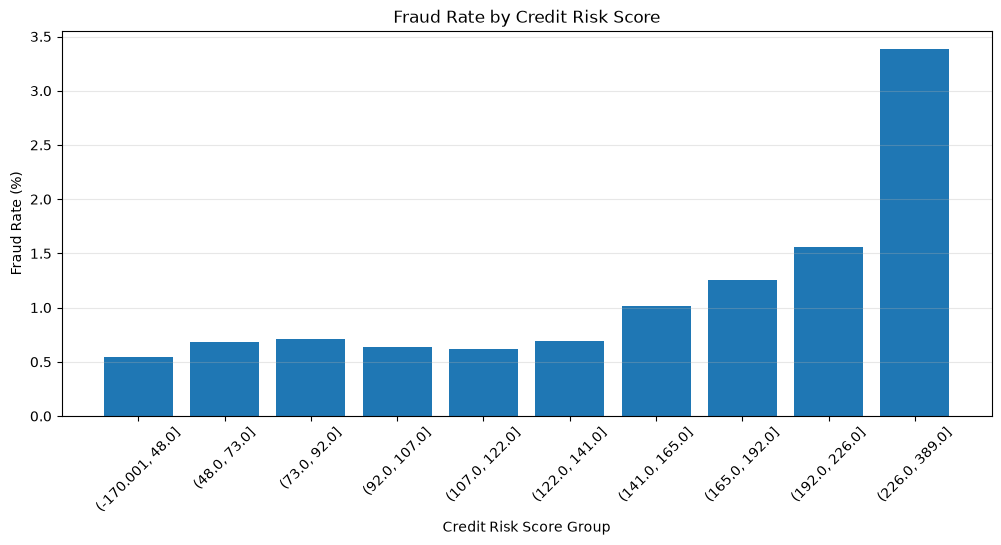

In [11]:
plt.figure(figsize=(12, 5))

plt.bar(
    credit_fraud["credit_risk_group"].astype(str),
    credit_fraud["fraud_rate"]
)

plt.xlabel("Credit Risk Score Group")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Credit Risk Score")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [12]:
#EDA theo name_email_similarity
df["name_email_group"] = pd.qcut(
    df["name_email_similarity"],
    q=10,
    duplicates="drop"
)

email_fraud = (
    df.groupby("name_email_group", observed=True)["fraud_bool"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

email_fraud["fraud_rate"] = email_fraud["mean"] * 100

email_fraud

,name_email_group,count,sum,mean,fraud_rate
0,"(-0.00099857, 0.107]",100000,2050,0.02050,2.050
1,"(0.107, 0.183]",100000,1862,0.01862,1.862
2,"(0.183, 0.272]",100000,1350,0.01350,1.350
3,"(0.272, 0.39]",100000,1089,0.01089,1.089
4,"(0.39, 0.492]",100000,708,0.00708,0.708
5,"(0.492, 0.588]",100000,695,0.00695,0.695
6,"(0.588, 0.707]",100000,753,0.00753,0.753
7,"(0.707, 0.806]",100000,999,0.00999,0.999
8,"(0.806, 0.883]",100000,835,0.00835,0.835
9,"(0.883, 1.0]",100000,688,0.00688,0.688


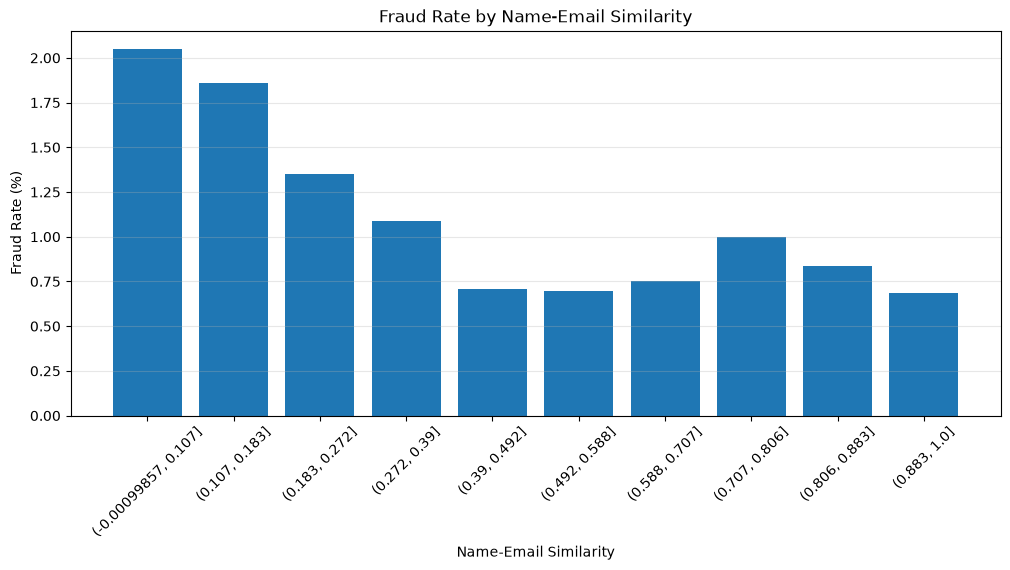

In [13]:
plt.figure(figsize=(12, 5))

plt.bar(
    email_fraud["name_email_group"].astype(str),
    email_fraud["fraud_rate"]
)

plt.xlabel("Name-Email Similarity")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Name-Email Similarity")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [14]:
#EDA theo foreign_request
foreign_fraud = (
    df.groupby("foreign_request")["fraud_bool"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

foreign_fraud["fraud_rate"] = foreign_fraud["mean"] * 100

foreign_fraud

,foreign_request,count,sum,mean,fraud_rate
0,0,974758,10474,0.010745,1.074523
1,1,25242,555,0.021987,2.198716


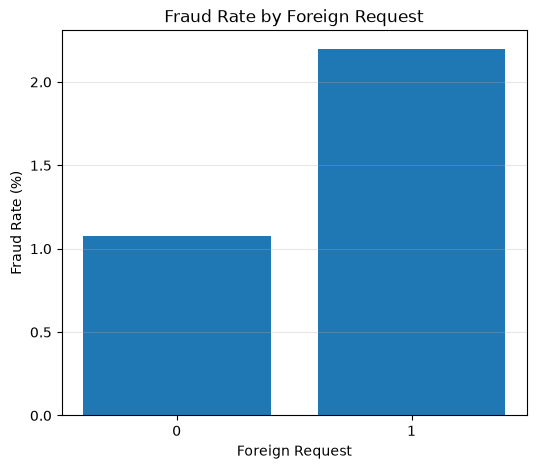

In [15]:
plt.figure(figsize=(6, 5))

plt.bar(
    foreign_fraud["foreign_request"].astype(str),
    foreign_fraud["fraud_rate"]
)

plt.xlabel("Foreign Request")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Foreign Request")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [16]:
# EDA theo device_os
device_fraud = (
    df.groupby("device_os")["fraud_bool"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

device_fraud["fraud_rate"] = device_fraud["mean"] * 100

device_fraud = device_fraud.sort_values(
    "fraud_rate",
    ascending=False
)

device_fraud

,device_os,count,sum,mean,fraud_rate
3,windows,263506,6507,0.024694,2.469393
1,macintosh,53826,752,0.013971,1.397094
4,x11,7228,81,0.011206,1.120642
2,other,342728,1974,0.005760,0.575967
0,linux,332712,1715,0.005155,0.515461


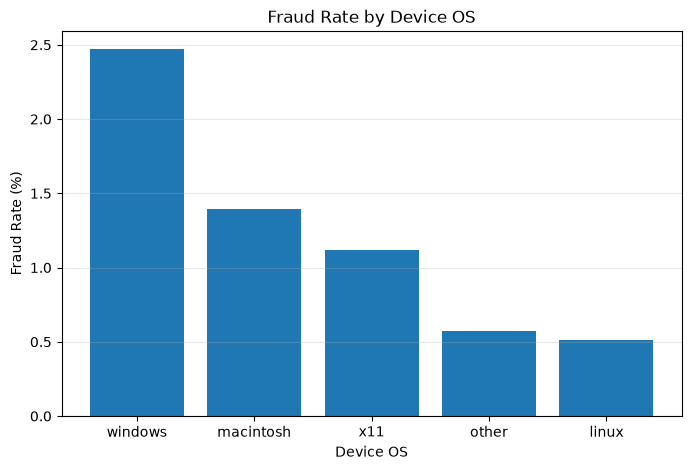

In [17]:
plt.figure(figsize=(8, 5))

plt.bar(
    device_fraud["device_os"],
    device_fraud["fraud_rate"]
)

plt.xlabel("Device OS")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Device OS")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [18]:
device_fraud[["device_os", "count", "sum", "fraud_rate"]]

,device_os,count,sum,fraud_rate
3,windows,263506,6507,2.469393
1,macintosh,53826,752,1.397094
4,x11,7228,81,1.120642
2,other,342728,1974,0.575967
0,linux,332712,1715,0.515461


In [19]:
#EDA theo month 
df["month"].value_counts().sort_index()

month
0    132440
1    127620
2    136979
3    150936
4    127691
5    119323
6    108168
7     96843
Name: count, dtype: int64

In [20]:
month_fraud = (
    df.groupby("month")["fraud_bool"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

month_fraud["fraud_rate"] = month_fraud["mean"] * 100

month_fraud

,month,count,sum,mean,fraud_rate
0,0,132440,1500,0.011326,1.132588
1,1,127620,1198,0.009387,0.938724
2,2,136979,1198,0.008746,0.874587
3,3,150936,1392,0.009222,0.922245
4,4,127691,1452,0.011371,1.137120
5,5,119323,1411,0.011825,1.182505
6,6,108168,1450,0.013405,1.340507
7,7,96843,1428,0.014746,1.474552


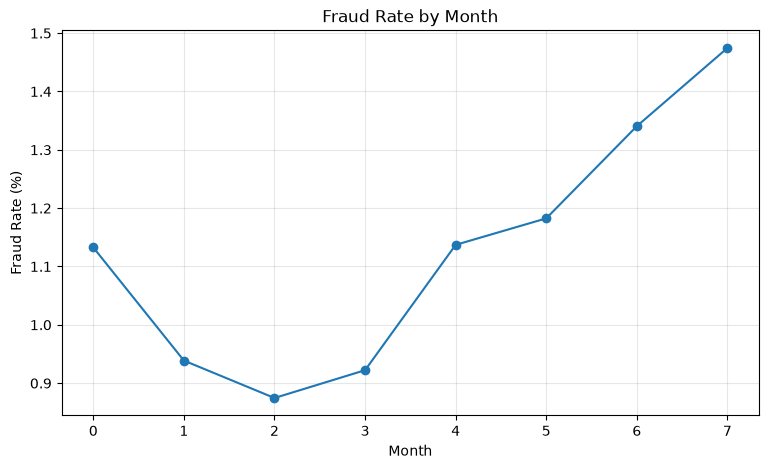

In [21]:
plt.figure(figsize=(9, 5))

plt.plot(
    month_fraud["month"],
    month_fraud["fraud_rate"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Month")
plt.grid(alpha=0.3)

plt.show()